In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd().parent
SUMMARY_PATH = PROJECT_ROOT / "experiments" / "exp2_all" / "experiment_summary.csv"

print("Project root:", PROJECT_ROOT)
print("Summary path:", SUMMARY_PATH)
print("Exists:", SUMMARY_PATH.exists())

df = pd.read_csv(SUMMARY_PATH)
print("Shape:", df.shape)
df.head()

amt = 25

Project root: /home/jacobhardy/capstone
Summary path: /home/jacobhardy/capstone/experiments/exp2_all/experiment_summary.csv
Exists: True
Shape: (5760, 33)


In [3]:
# Drop duplicate run rows if any somehow exist
df = df.drop_duplicates().copy()

# Keep only rows with a valid MAE
df = df.dropna(subset=["mae_m"]).copy()

# Sort once by MAE ascending
df = df.sort_values("mae_m", ascending=True).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Cleaned shape: (5760, 33)

Columns:
['run_name', 'run_dir', 'seq_len', 'batch_size', 'learning_rate', 'weight_decay', 'dropout', 'kernel_size', 'tcn_channels', 'dilations', 'max_epochs', 'min_epochs', 'loss_stability_threshold', 'epochs_trained', 'stopped_early', 'final_train_loss', 'rmse_m', 'mae_m', 'median_m', 'p95_m', 'q1_m', 'q3_m', 'iqr_m', 'lower_bound_m', 'upper_bound_m', 'outlier_count', 'outlier_percent', 'large_error_threshold_m', 'large_error_count', 'num_outlier_maps_saved', 'results_df_path', 'train_loss_history_path', 'run_log_path']


In [4]:
total_runs = len(df)
best_mae = df["mae_m"].min()
median_mae = df["mae_m"].median()
worst_mae = df["mae_m"].max()

print(f"Total completed runs: {total_runs}")
print(f"Best MAE: {best_mae:.4f}")
print(f"Median MAE: {median_mae:.4f}")
print(f"Worst MAE: {worst_mae:.4f}")

Total completed runs: 5760
Best MAE: 822.6158
Median MAE: 1017.6450
Worst MAE: 1786.1584


In [5]:
cols_to_show = [
    "run_name",
    "seq_len",
    "learning_rate",
    "batch_size",
    "dropout",
    "kernel_size",
    "tcn_channels",
    "dilations",
    "epochs_trained",
    "mae_m",
    "rmse_m",
    "median_m",
    "p95_m",
    "outlier_percent",
    "run_dir",
]

top_10 = df.nsmallest(amt, "mae_m")[cols_to_show].copy()
top_10["rank_by_mae"] = range(1, len(top_10) + 1)
top_10 = top_10[["rank_by_mae"] + cols_to_show]

bottom_3 = df.nlargest(3, "mae_m")[cols_to_show].copy()
bottom_3["rank_from_worst"] = range(1, len(bottom_3) + 1)
bottom_3 = bottom_3[["rank_from_worst"] + cols_to_show]

print(f"Top {amt} best by MAE")
display(top_10)

print("Bottom 3 worst by MAE")
display(bottom_3)

Top 25 best by MAE


,rank_by_mae,run_name,seq_len,learning_rate,batch_size,dropout,kernel_size,tcn_channels,dilations,epochs_trained,mae_m,rmse_m,median_m,p95_m,outlier_percent,run_dir
0,1,20260406_060331_seq24_bs256_lr1e-03_do0.2_ks5_...,24,0.0010,256,0.2,5,"[64, 128, 256]","[1, 2, 4]",23,822.615845,3330.698975,247.694946,2528.842773,12.862109,experiments/20260406_060331_seq24_bs256_lr1e-0...
1,2,20260406_060545_seq24_bs256_lr1e-03_do0.3_ks5_...,24,0.0010,256,0.3,5,"[64, 128, 256]","[1, 3, 9]",20,826.344849,3331.188721,258.350250,2489.090088,12.900734,experiments/20260406_060545_seq24_bs256_lr1e-0...
2,3,20260406_060541_seq24_bs256_lr1e-03_do0.3_ks5_...,24,0.0010,256,0.3,5,"[64, 128, 256]","[1, 2, 4]",23,827.403259,3332.227295,255.758377,2441.859863,12.900734,experiments/20260406_060541_seq24_bs256_lr1e-0...
3,4,20260406_070816_seq24_bs256_lr3e-04_do0.3_ks5_...,24,0.0003,256,0.3,5,"[64, 128, 256]","[1, 3, 9]",23,832.263611,3328.680420,266.379395,2631.789307,12.900734,experiments/20260406_070816_seq24_bs256_lr3e-0...
4,5,20260406_070151_seq24_bs256_lr3e-04_do0.1_ks3_...,24,0.0003,256,0.1,3,"[64, 128, 256]","[1, 2, 4]",34,833.999634,3318.996582,262.863281,2720.935059,12.282735,experiments/20260406_070151_seq24_bs256_lr3e-0...
5,6,20260406_071400_seq24_bs256_lr3e-04_do0.5_ks5_...,24,0.0003,256,0.5,5,"[64, 128, 256]","[1, 3, 9]",28,834.541321,3331.682861,267.413116,2416.240723,13.055234,experiments/20260406_071400_seq24_bs256_lr3e-0...
6,7,20260406_071405_seq24_bs256_lr3e-04_do0.5_ks5_...,24,0.0003,256,0.5,5,"[64, 128, 256]","[1, 4, 10]",28,834.956726,3332.696777,270.051941,2422.089355,13.093859,experiments/20260406_071405_seq24_bs256_lr3e-0...
7,8,20260406_070537_seq24_bs256_lr3e-04_do0.2_ks5_...,24,0.0003,256,0.2,5,"[64, 128, 256]","[1, 3, 9]",23,835.173889,3327.879639,261.236725,2640.369141,12.977984,experiments/20260406_070537_seq24_bs256_lr3e-0...
8,9,20260406_070421_seq24_bs256_lr3e-04_do0.2_ks3_...,24,0.0003,256,0.2,3,"[64, 128, 256]","[1, 3, 9]",28,836.937988,3334.120850,264.537811,2587.594482,13.016609,experiments/20260406_070421_seq24_bs256_lr3e-0...
9,10,20260406_064723_seq24_bs128_lr3e-04_do0.1_ks2_...,24,0.0003,128,0.1,2,"[64, 128, 256]","[1, 3, 9]",24,837.240540,3334.976562,285.099915,2395.794189,12.784859,experiments/20260406_064723_seq24_bs128_lr3e-0...


Bottom 3 worst by MAE


,rank_from_worst,run_name,seq_len,learning_rate,batch_size,dropout,kernel_size,tcn_channels,dilations,epochs_trained,mae_m,rmse_m,median_m,p95_m,outlier_percent,run_dir
5759,1,20260405_222859_seq8_bs32_lr1e-03_do0.1_ks3_ch...,8,0.001,32,0.1,3,"[32, 64, 128]","[1, 2, 4]",6,1786.158447,3148.848877,1291.322021,5210.044434,7.878788,experiments/20260405_222859_seq8_bs32_lr1e-03_...
5758,2,20260405_230908_seq8_bs64_lr1e-03_do0.5_ks3_ch...,8,0.001,64,0.5,3,"[32, 64, 128]","[1, 4, 10]",5,1706.305786,3106.096680,1213.073486,5113.276367,7.909091,experiments/20260405_230908_seq8_bs64_lr1e-03_...
5757,3,20260405_230902_seq8_bs64_lr1e-03_do0.5_ks3_ch...,8,0.001,64,0.5,3,"[32, 64, 128]","[1, 3, 9]",5,1701.944214,3104.337891,1206.617920,5110.583496,7.924242,experiments/20260405_230902_seq8_bs64_lr1e-03_...


In [6]:
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

top_10.to_csv(OUTPUT_DIR / "top_10_by_mae.csv", index=False)
bottom_3.to_csv(OUTPUT_DIR / "bottom_3_by_mae.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "top_10_by_mae.csv")
print(OUTPUT_DIR / "bottom_3_by_mae.csv")

Saved:
/home/jacobhardy/capstone/notebooks/analysis_outputs/top_10_by_mae.csv
/home/jacobhardy/capstone/notebooks/analysis_outputs/bottom_3_by_mae.csv


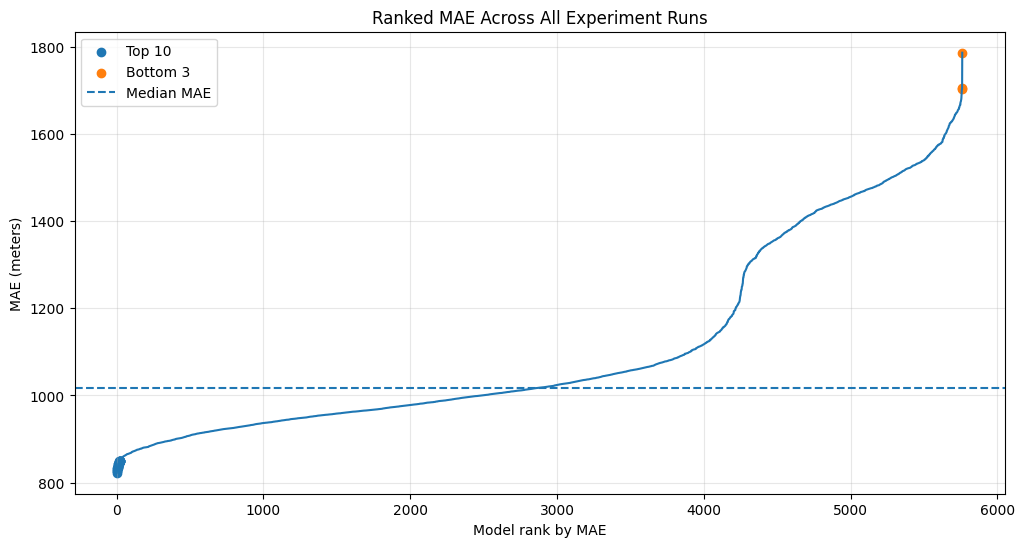

In [7]:
ranked_df = df.sort_values("mae_m", ascending=True).reset_index(drop=True).copy()
ranked_df["rank"] = np.arange(1, len(ranked_df) + 1)

plt.figure(figsize=(12, 6))
plt.plot(ranked_df["rank"], ranked_df["mae_m"])

# Highlight top 10
top10_idx = ranked_df.index[:amt]
plt.scatter(
    ranked_df.loc[top10_idx, "rank"],
    ranked_df.loc[top10_idx, "mae_m"],
    label="Top 10"
)

# Highlight bottom 3
bottom3_idx = ranked_df.index[-3:]
plt.scatter(
    ranked_df.loc[bottom3_idx, "rank"],
    ranked_df.loc[bottom3_idx, "mae_m"],
    label="Bottom 3"
)

plt.axhline(ranked_df["mae_m"].median(), linestyle="--", label="Median MAE")

plt.xlabel("Model rank by MAE")
plt.ylabel("MAE (meters)")
plt.title("Ranked MAE Across All Experiment Runs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

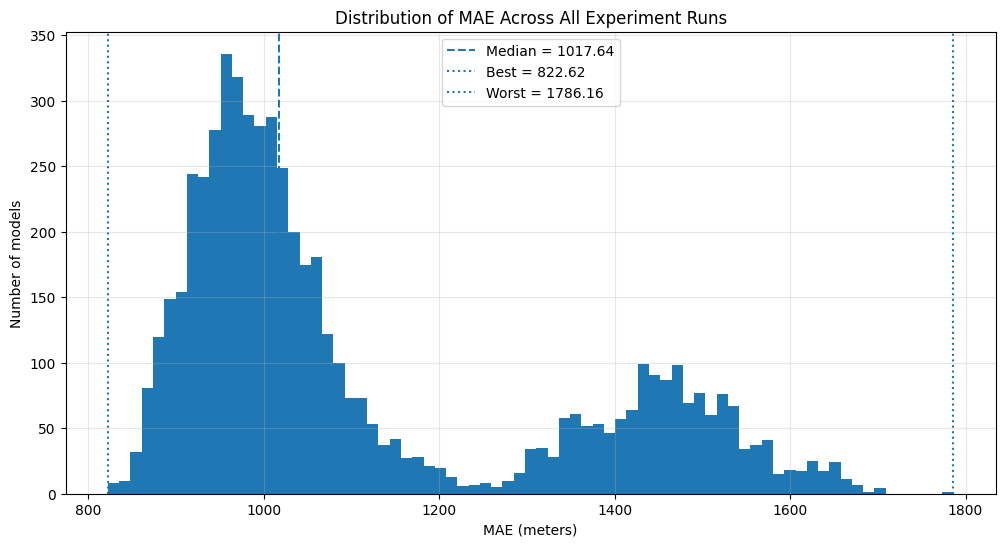

In [8]:
plt.figure(figsize=(12, 6))
plt.hist(df["mae_m"], bins=75)
plt.axvline(df["mae_m"].median(), linestyle="--", label=f"Median = {df['mae_m'].median():.2f}")
plt.axvline(df["mae_m"].min(), linestyle=":", label=f"Best = {df['mae_m'].min():.2f}")
plt.axvline(df["mae_m"].max(), linestyle=":", label=f"Worst = {df['mae_m'].max():.2f}")

plt.xlabel("MAE (meters)")
plt.ylabel("Number of models")
plt.title("Distribution of MAE Across All Experiment Runs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1000x600 with 0 Axes>

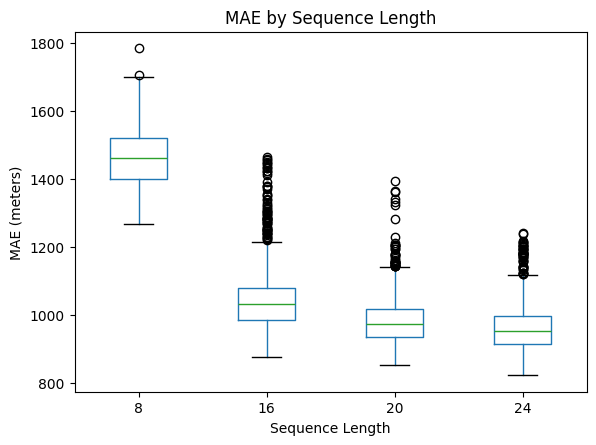

In [9]:
plt.figure(figsize=(10, 6))
df.boxplot(column="mae_m", by="seq_len", grid=False)
plt.suptitle("")
plt.title("MAE by Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("MAE (meters)")
plt.show()

<Figure size 1000x600 with 0 Axes>

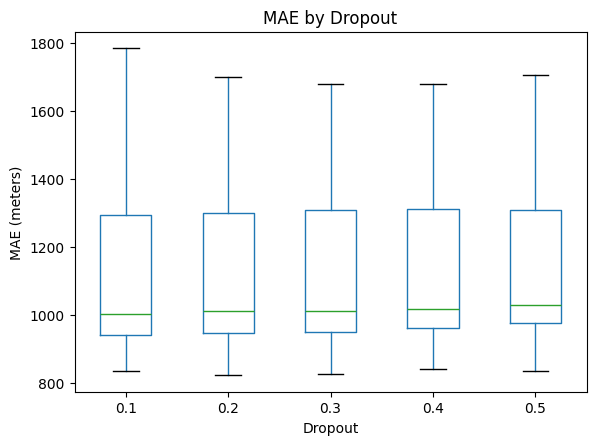

In [10]:
plt.figure(figsize=(10, 6))
df.boxplot(column="mae_m", by="dropout", grid=False)
plt.suptitle("")
plt.title("MAE by Dropout")
plt.xlabel("Dropout")
plt.ylabel("MAE (meters)")
plt.show()

<Figure size 1000x600 with 0 Axes>

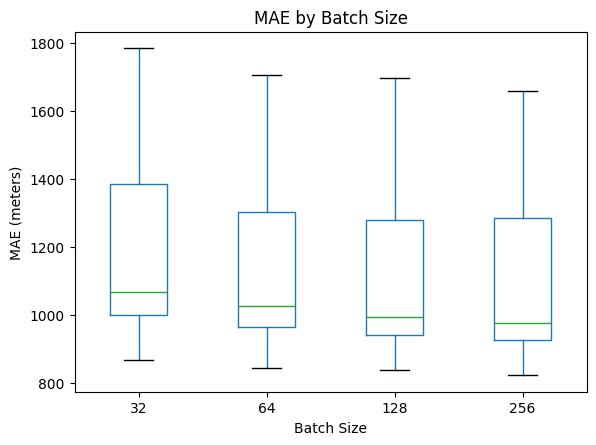

In [11]:
plt.figure(figsize=(10, 6))
df.boxplot(column="mae_m", by="batch_size", grid=False)
plt.suptitle("")
plt.title("MAE by Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("MAE (meters)")
plt.show()

<Figure size 1000x600 with 0 Axes>

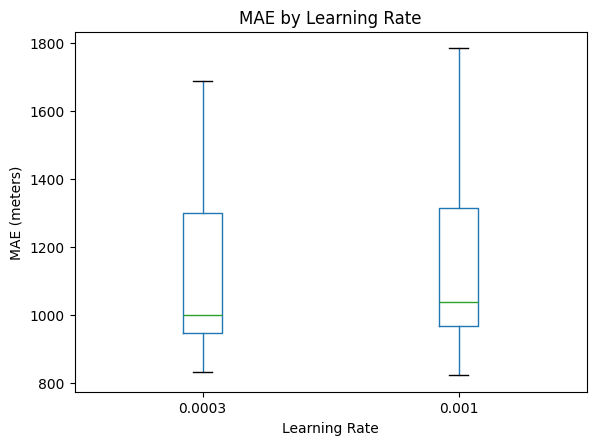

In [12]:
plt.figure(figsize=(10, 6))
df.boxplot(column="mae_m", by="learning_rate", grid=False)
plt.suptitle("")
plt.title("MAE by Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("MAE (meters)")
plt.show()

<Figure size 1000x600 with 0 Axes>

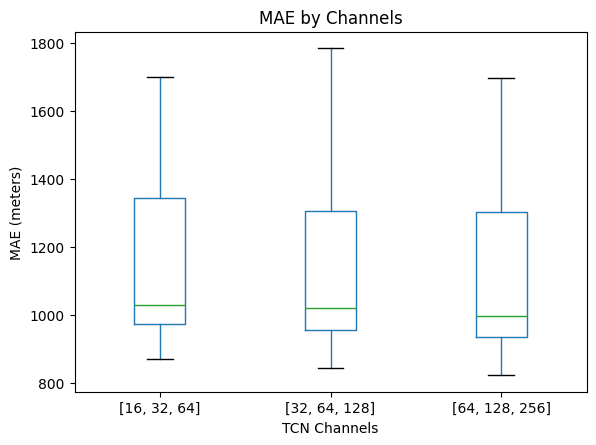

In [13]:
plt.figure(figsize=(10, 6))
df.boxplot(column="mae_m", by="tcn_channels", grid=False)
plt.suptitle("")
plt.title("MAE by Channels")
plt.xlabel("TCN Channels")
plt.ylabel("MAE (meters)")
plt.show()

<Figure size 1000x600 with 0 Axes>

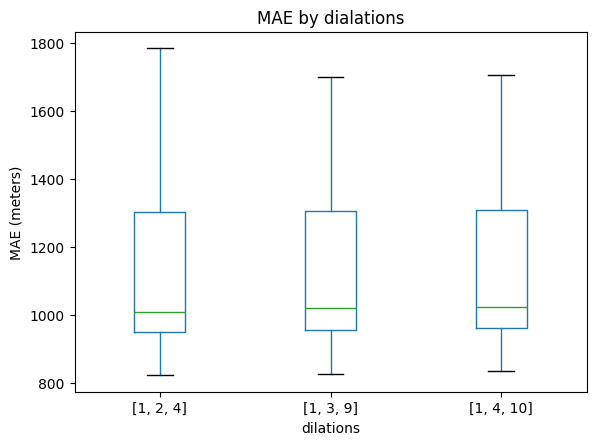

In [14]:
plt.figure(figsize=(10, 6))
df.boxplot(column="mae_m", by="dilations", grid=False)
plt.suptitle("")
plt.title("MAE by dialations")
plt.xlabel("dilations")
plt.ylabel("MAE (meters)")
plt.show()

<Figure size 1000x600 with 0 Axes>

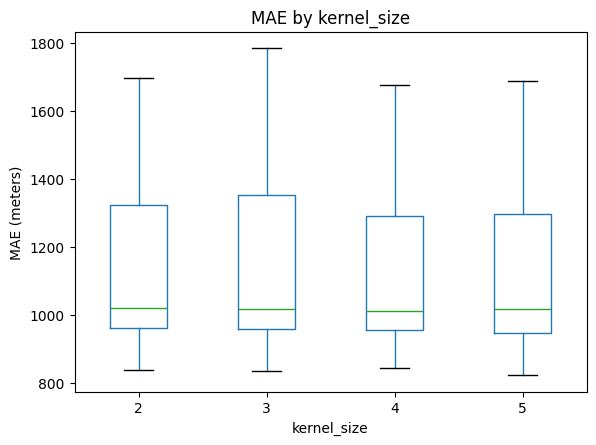

In [15]:
plt.figure(figsize=(10, 6))
df.boxplot(column="mae_m", by="kernel_size", grid=False)
plt.suptitle("")
plt.title("MAE by kernel_size")
plt.xlabel("kernel_size")
plt.ylabel("MAE (meters)")
plt.show()

In [16]:
print("Top 10 seq_len frequency")
display(top_10["seq_len"].value_counts().rename_axis("seq_len").reset_index(name="count"))

print("Top 10 dropout frequency")
display(top_10["dropout"].value_counts().rename_axis("dropout").reset_index(name="count"))

print("Top 10 batch_size frequency")
display(top_10["batch_size"].value_counts().rename_axis("batch_size").reset_index(name="count"))

print("Top 10 learning_rate frequency")
display(top_10["learning_rate"].value_counts().rename_axis("learning_rate").reset_index(name="count"))

print("Top 10 kernel_size frequency")
display(top_10["kernel_size"].value_counts().rename_axis("kernel_size").reset_index(name="count"))

print("Top 10 tcn_channels frequency")
display(top_10["tcn_channels"].value_counts().rename_axis("tcn_channels").reset_index(name="count"))

print("Top 10 dilations frequency")
display(top_10["dilations"].value_counts().rename_axis("dilations").reset_index(name="count"))

Top 10 seq_len frequency


,seq_len,count
0,24,25


Top 10 dropout frequency


,dropout,count
0,0.2,6
1,0.3,6
2,0.1,5
3,0.5,5
4,0.4,3


Top 10 batch_size frequency


...

,kernel_size,count
0,5,17
1,3,5
2,2,2
3,4,1


Top 10 tcn_channels frequency


,tcn_channels,count
0,"[64, 128, 256]",18
1,"[32, 64, 128]",7


Top 10 dilations frequency


,dilations,count
0,"[1, 3, 9]",11
1,"[1, 2, 4]",10
2,"[1, 4, 10]",4


In [17]:
selected_runs = pd.concat([top_10, bottom_3], ignore_index=True, sort=False)
selected_runs

,rank_by_mae,run_name,seq_len,learning_rate,batch_size,dropout,kernel_size,tcn_channels,dilations,epochs_trained,mae_m,rmse_m,median_m,p95_m,outlier_percent,run_dir,rank_from_worst
0,1.0,20260406_060331_seq24_bs256_lr1e-03_do0.2_ks5_...,24,0.0010,256,0.2,5,"[64, 128, 256]","[1, 2, 4]",23,822.615845,3330.698975,247.694946,2528.842773,12.862109,experiments/20260406_060331_seq24_bs256_lr1e-0...,NaN
1,2.0,20260406_060545_seq24_bs256_lr1e-03_do0.3_ks5_...,24,0.0010,256,0.3,5,"[64, 128, 256]","[1, 3, 9]",20,826.344849,3331.188721,258.350250,2489.090088,12.900734,experiments/20260406_060545_seq24_bs256_lr1e-0...,NaN
2,3.0,20260406_060541_seq24_bs256_lr1e-03_do0.3_ks5_...,24,0.0010,256,0.3,5,"[64, 128, 256]","[1, 2, 4]",23,827.403259,3332.227295,255.758377,2441.859863,12.900734,experiments/20260406_060541_seq24_bs256_lr1e-0...,NaN
3,4.0,20260406_070816_seq24_bs256_lr3e-04_do0.3_ks5_...,24,0.0003,256,0.3,5,"[64, 128, 256]","[1, 3, 9]",23,832.263611,3328.680420,266.379395,2631.789307,12.900734,experiments/20260406_070816_seq24_bs256_lr3e-0...,NaN
4,5.0,20260406_070151_seq24_bs256_lr3e-04_do0.1_ks3_...,24,0.0003,256,0.1,3,"[64, 128, 256]","[1, 2, 4]",34,833.999634,3318.996582,262.863281,2720.935059,12.282735,experiments/20260406_070151_seq24_bs256_lr3e-0...,NaN
5,6.0,20260406_071400_seq24_bs256_lr3e-04_do0.5_ks5_...,24,0.0003,256,0.5,5,"[64, 128, 256]","[1, 3, 9]",28,834.541321,3331.682861,267.413116,2416.240723,13.055234,experiments/20260406_071400_seq24_bs256_lr3e-0...,NaN
6,7.0,20260406_071405_seq24_bs256_lr3e-04_do0.5_ks5_...,24,0.0003,256,0.5,5,"[64, 128, 256]","[1, 4, 10]",28,834.956726,3332.696777,270.051941,2422.089355,13.093859,experiments/20260406_071405_seq24_bs256_lr3e-0...,NaN
7,8.0,20260406_070537_seq24_bs256_lr3e-04_do0.2_ks5_...,24,0.0003,256,0.2,5,"[64, 128, 256]","[1, 3, 9]",23,835.173889,3327.879639,261.236725,2640.369141,12.977984,experiments/20260406_070537_seq24_bs256_lr3e-0...,NaN
8,9.0,20260406_070421_seq24_bs256_lr3e-04_do0.2_ks3_...,24,0.0003,256,0.2,3,"[64, 128, 256]","[1, 3, 9]",28,836.937988,3334.120850,264.537811,2587.594482,13.016609,experiments/20260406_070421_seq24_bs256_lr3e-0...,NaN
9,10.0,20260406_064723_seq24_bs128_lr3e-04_do0.1_ks2_...,24,0.0003,128,0.1,2,"[64, 128, 256]","[1, 3, 9]",24,837.240540,3334.976562,285.099915,2395.794189,12.784859,experiments/20260406_064723_seq24_bs128_lr3e-0...,NaN


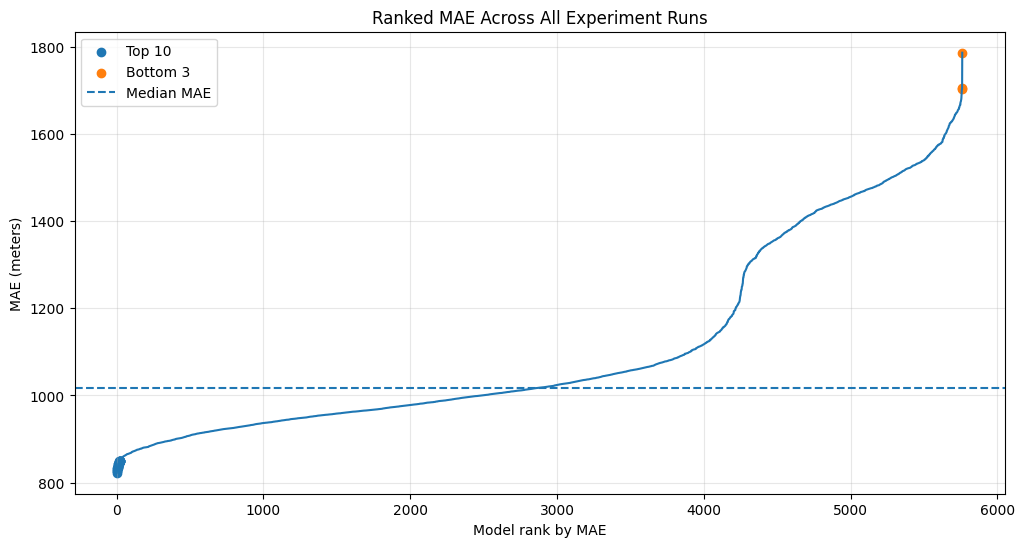

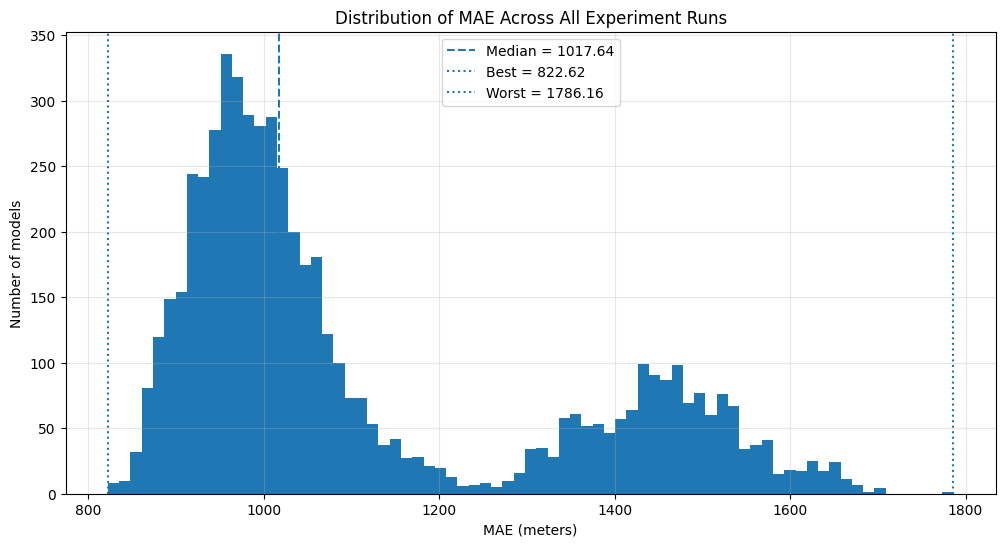

Saved figures to: /home/jacobhardy/capstone/notebooks/analysis_outputs/figures


In [18]:
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Ranked MAE curve
plt.figure(figsize=(12, 6))
plt.plot(ranked_df["rank"], ranked_df["mae_m"])
plt.scatter(ranked_df.loc[top10_idx, "rank"], ranked_df.loc[top10_idx, "mae_m"], label="Top 10")
plt.scatter(ranked_df.loc[bottom3_idx, "rank"], ranked_df.loc[bottom3_idx, "mae_m"], label="Bottom 3")
plt.axhline(ranked_df["mae_m"].median(), linestyle="--", label="Median MAE")
plt.xlabel("Model rank by MAE")
plt.ylabel("MAE (meters)")
plt.title("Ranked MAE Across All Experiment Runs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "ranked_mae_curve.png", dpi=200, bbox_inches="tight")
plt.show()

# Histogram
plt.figure(figsize=(12, 6))
plt.hist(df["mae_m"], bins=75)
plt.axvline(df["mae_m"].median(), linestyle="--", label=f"Median = {df['mae_m'].median():.2f}")
plt.axvline(df["mae_m"].min(), linestyle=":", label=f"Best = {df['mae_m'].min():.2f}")
plt.axvline(df["mae_m"].max(), linestyle=":", label=f"Worst = {df['mae_m'].max():.2f}")
plt.xlabel("MAE (meters)")
plt.ylabel("Number of models")
plt.title("Distribution of MAE Across All Experiment Runs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "mae_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved figures to:", FIG_DIR)